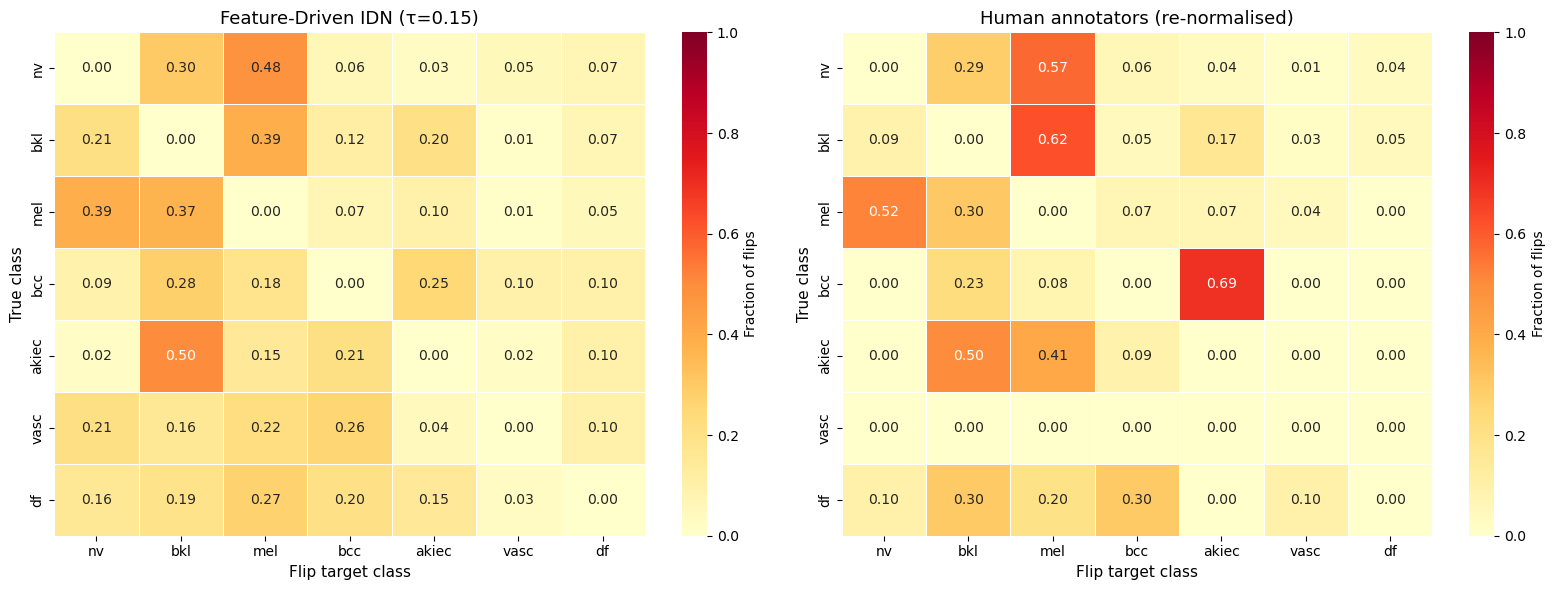

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Human confusion matrix (rows = true class, cols = predicted class)
# Order: AKIEC, BCC, BKL, DF, MEL, NV, VASC
human_raw = np.array([
    [0.488, 0.047, 0.256, 0.000, 0.209, 0.000, 0.000],
    [0.097, 0.860, 0.032, 0.000, 0.011, 0.000, 0.000],
    [0.032, 0.009, 0.806, 0.009, 0.120, 0.018, 0.005],
    [0.000, 0.068, 0.068, 0.773, 0.045, 0.023, 0.023],
    [0.018, 0.018, 0.082, 0.000, 0.731, 0.140, 0.012],
    [0.004, 0.007, 0.032, 0.004, 0.064, 0.888, 0.001],
    [0.000, 0.000, 0.000, 0.000, 0.000, 0.000, 1.000],
])
human_classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

# Reorder to match your class order
your_classes = ["nv", "bkl", "mel", "bcc", "akiec", "vasc", "df"]
human_df = pd.DataFrame(human_raw, index=human_classes, columns=human_classes)
human_df = human_df.loc[your_classes, your_classes]

# Zero out diagonal (correct classifications are not flips)
# and re-normalize each row to sum to 1
human_arr = human_df.values.copy()
np.fill_diagonal(human_arr, 0.0)
row_sums = human_arr.sum(axis=1, keepdims=True)
# Avoid division by zero (vasc row becomes all-zero after zeroing diagonal)
row_sums = np.where(row_sums == 0, 1, row_sums)
human_normalized = human_arr / row_sums
human_normalized_df = pd.DataFrame(
    human_normalized, index=your_classes, columns=your_classes
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Your Feature-Driven IDN confusion matrix (tau=0.15) — paste your values here
your_matrix = np.array([
    [0.00, 0.30, 0.48, 0.06, 0.03, 0.05, 0.07],  # nv
    [0.21, 0.00, 0.39, 0.12, 0.20, 0.01, 0.07],  # bkl
    [0.39, 0.37, 0.00, 0.07, 0.10, 0.01, 0.05],  # mel
    [0.09, 0.28, 0.18, 0.00, 0.25, 0.10, 0.10],  # bcc
    [0.02, 0.50, 0.15, 0.21, 0.00, 0.02, 0.10],  # akiec
    [0.21, 0.16, 0.22, 0.26, 0.04, 0.00, 0.10],  # vasc
    [0.16, 0.19, 0.27, 0.20, 0.15, 0.03, 0.00],  # df
])
your_df = pd.DataFrame(your_matrix, index=your_classes, columns=your_classes)

for ax, matrix, title in zip(
    axes,
    [your_df, human_normalized_df],
    ["Feature-Driven IDN (τ=0.15)", "Human annotators (re-normalised)"]
):
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="YlOrRd",
        vmin=0, vmax=1, linewidths=0.5, ax=ax,
        cbar_kws={"label": "Fraction of flips"}
    )
    ax.set_xlabel("Flip target class", fontsize=11)
    ax.set_ylabel("True class", fontsize=11)
    ax.set_title(title, fontsize=13)

plt.tight_layout()
# plt.savefig("confusion_comparison.png", dpi=150)
plt.show()

In [3]:
human = human_normalized_df.values  # from earlier

normalized_idn = np.array([
    [0.00, 0.25, 0.26, 0.08, 0.17, 0.15, 0.09],
    [0.03, 0.00, 0.07, 0.10, 0.25, 0.23, 0.32],
    [0.15, 0.14, 0.00, 0.24, 0.06, 0.25, 0.16],
    [0.12, 0.17, 0.33, 0.00, 0.11, 0.12, 0.15],
    [0.07, 0.23, 0.22, 0.09, 0.00, 0.38, 0.01],
    [0.03, 0.36, 0.16, 0.20, 0.08, 0.00, 0.19],
    [0.15, 0.07, 0.12, 0.21, 0.10, 0.34, 0.00],
])

feature_driven = np.array([
    [0.00, 0.30, 0.48, 0.06, 0.03, 0.05, 0.07],
    [0.21, 0.00, 0.39, 0.12, 0.20, 0.01, 0.07],
    [0.39, 0.37, 0.00, 0.07, 0.10, 0.01, 0.05],
    [0.09, 0.28, 0.18, 0.00, 0.25, 0.10, 0.10],
    [0.02, 0.50, 0.15, 0.21, 0.00, 0.02, 0.10],
    [0.21, 0.16, 0.22, 0.26, 0.04, 0.00, 0.10],
    [0.16, 0.19, 0.27, 0.20, 0.15, 0.03, 0.00],
])

mae_normalized = np.abs(normalized_idn - human).mean()
mae_feature    = np.abs(feature_driven - human).mean()

# Per-class MAE to see where each method is closer
per_class_mae = pd.DataFrame({
    "class":      your_classes,
    "normalized": np.abs(normalized_idn - human).mean(axis=1),
    "feature_driven": np.abs(feature_driven - human).mean(axis=1),
})

print(f"Overall MAE — Normalized IDN:     {mae_normalized:.4f}")
print(f"Overall MAE — Feature-Driven IDN: {mae_feature:.4f}")
print()
print(per_class_mae.to_string(index=False))

Overall MAE — Normalized IDN:     0.1431
Overall MAE — Feature-Driven IDN: 0.0807

class  normalized  feature_driven
   nv    0.099184        0.027041
  bkl    0.175722        0.070762
  mel    0.153968        0.045132
  bcc    0.183265        0.126531
akiec    0.131429        0.073772
 vasc    0.145714        0.141429
   df    0.112102        0.080126
